In [2]:
! pip install numpy pandas matplotlib seaborn
! pip install scikit-learn imbalanced-learn statsmodels

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\sravan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\sravan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings('ignore')

The data provided contains information about various real estate properties. The columns represent the following:

id: The unique identifier for the property.

date: The date the property was sold.

price: The sale price of the property.

bedrooms: The number of bedrooms in the property.

bathrooms: The number of bathrooms in the property.

sqft_living: The square footage of the living area in the property.

sqft_lot: The square footage of the lot or land the property is on.

floors: The number of floors in the property.

waterfront: A binary indicator (0 or 1) for whether the property has a waterfront view.

view: A numeric indicator (0-4) for the quality of the view from the property.

condition: A numeric indicator (1-5) for the overall condition of the property.

grade: A numeric indicator (1-13) for the overall quality of the property.

sqft_above: The square footage of the above-ground living area.

sqft_basement: The square footage of the basement living area.

yr_built: The year the property was built.

yr_renovated: The year the property was last renovated.

zipcode: The ZIP code the property is located in.

lat: The latitude coordinate of the property's location.

long: The longitude coordinate of the property's location.

sqft_living15: The square footage of the living area of the nearest 15 properties.

sqft_lot15: The square footage of the lot of the nearest 15 properties. This data would be useful for analyzing real estate trends, property characteristics, and potential factors that influence property prices.

In [4]:
df = pd.read_csv(r"C:\Users\sravan\Downloads\kc_house_data.csv")
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


# File Handling

In [ ]:
df.drop(['id','date'],axis = 1,inplace = True)

In [ ]:
df

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,3,2.50,1530,1131,3.0,0,0,3,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,400000.0,4,2.50,2310,5813,2.0,0,0,3,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,402101.0,2,0.75,1020,1350,2.0,0,0,3,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,400000.0,3,2.50,1600,2388,2.0,0,0,3,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(5)

In [ ]:
df.drop_duplicates(inplace = True)

# EDA

In [ ]:
columns = list(set(df.columns))

In [ ]:
df.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [ ]:
Cat_features = ['waterfront','view']

In [ ]:
num_features = list(set(columns) - set(Cat_features))

In [ ]:
num_features

['yr_built',
 'zipcode',
 'bedrooms',
 'long',
 'sqft_living15',
 'sqft_basement',
 'bathrooms',
 'sqft_lot',
 'sqft_above',
 'price',
 'sqft_lot15',
 'floors',
 'lat',
 'yr_renovated',
 'sqft_living',
 'grade',
 'condition']

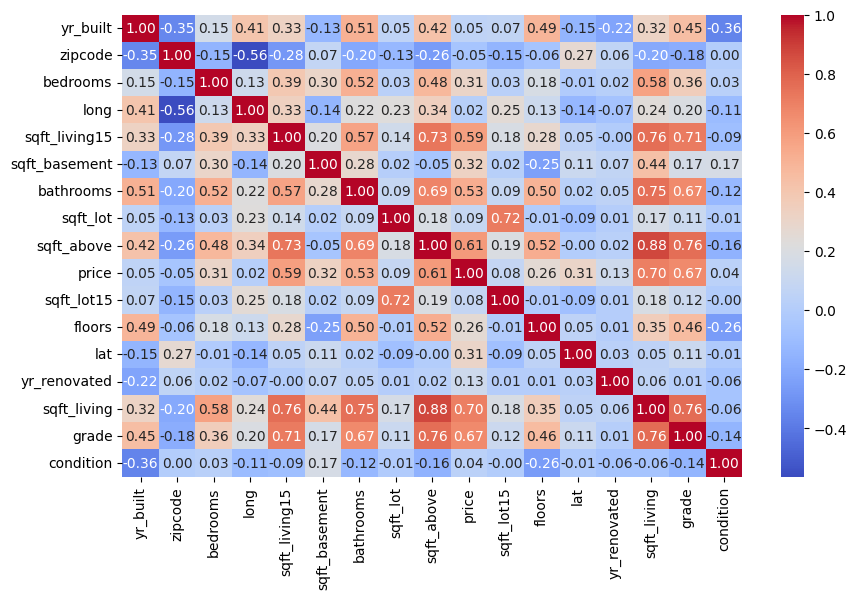

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

Let us look at the features which have much significant co-relation with price columns


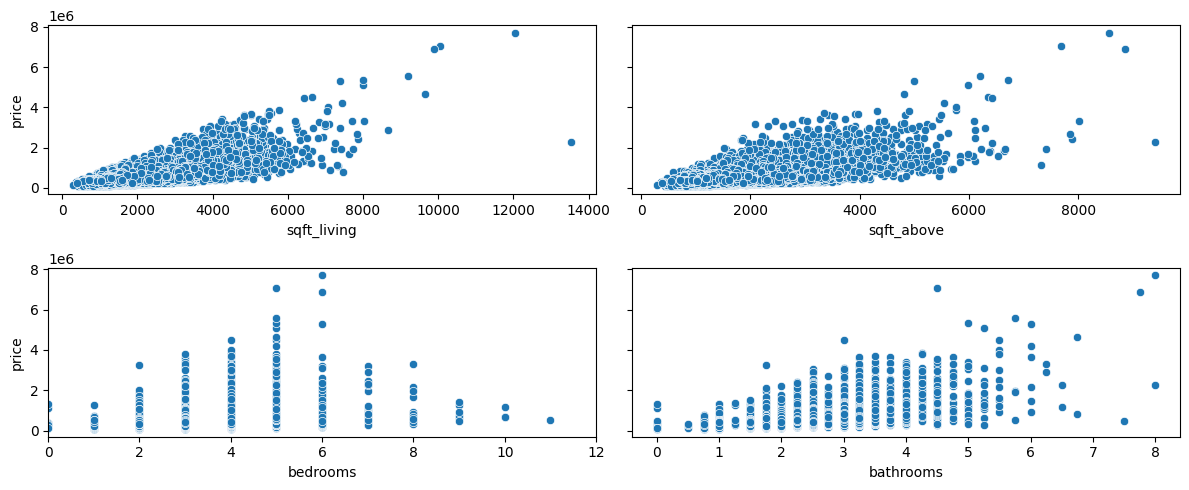

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(12, 5), sharey=True)

sns.scatterplot(x=df['sqft_living'], y=df['price'], ax=ax[0,0])
ax[0,0].set_xlabel('sqft_living')
ax[0,0].set_ylabel('price')

sns.scatterplot(x= df['sqft_above'], y =df['price'], ax = ax[0,1])
ax[0,1].set_xlabel('sqft_above')
ax[0,1].set_ylabel('price')

sns.scatterplot(x= df['bedrooms'], y =df['price'], ax = ax[1,0])
ax[1,0].set_xlim(0,12)
ax[1,0].set_xlabel('bedrooms')
ax[1,0].set_ylabel('price')

sns.scatterplot(x= df['bathrooms'], y =df['price'], ax = ax[1,1])
ax[1,1].set_xlabel('bathrooms')
ax[1,1].set_ylabel('price')

plt.tight_layout()
plt.show()

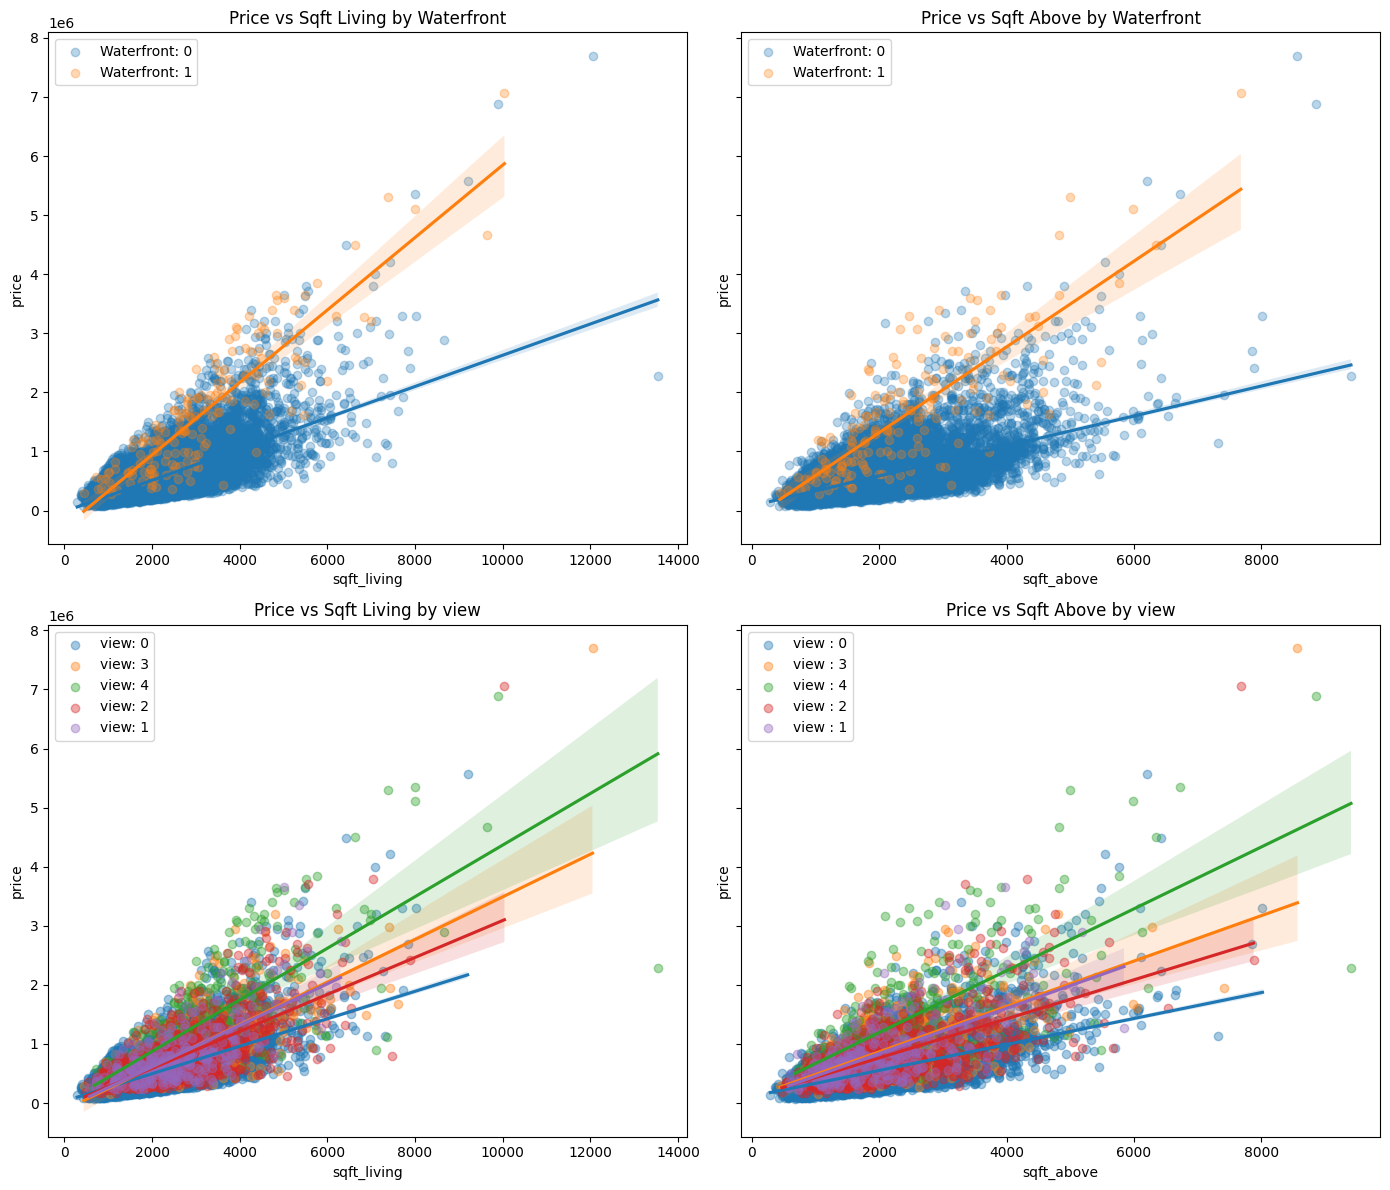

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(14, 12), sharey=True)

# Plot for sqft_living vs price with waterfront hue
for waterfront_val in df['waterfront'].unique():
    subset_df = df[df['waterfront'] == waterfront_val]
    sns.regplot(x='sqft_living', y='price', data=subset_df, ax=ax[0, 0],
                label=f'Waterfront: {waterfront_val}', scatter_kws={'alpha':0.3})
ax[0, 0].set_xlabel('sqft_living')
ax[0, 0].set_ylabel('price')
ax[0, 0].set_title('Price vs Sqft Living by Waterfront')
ax[0, 0].legend()

# Plot for sqft_above vs price with waterfront hue
for waterfront_val in df['waterfront'].unique():
    subset_df = df[df['waterfront'] == waterfront_val]
    sns.regplot(x='sqft_above', y='price', data=subset_df, ax=ax[0, 1],
                label=f'Waterfront: {waterfront_val}', scatter_kws={'alpha':0.3})
ax[0, 1].set_xlabel('sqft_above')
ax[0, 1].set_title('Price vs Sqft Above by Waterfront')
ax[0, 1].legend()

for view_val in df['view'].unique():
    subset_df = df[df['view'] == view_val]
    sns.regplot(x='sqft_living', y='price', data=subset_df, ax=ax[1, 0],
                label = f'view: {view_val}', scatter_kws={'alpha':0.4})
ax[1, 0].set_xlabel('sqft_living')
ax[1, 0].set_title('Price vs Sqft Living by view')
ax[1, 0].legend()

for view_val in df['view'].unique():
    subset_df = df[df['view'] == view_val]
    sns.regplot(x = 'sqft_above',y = 'price', data = subset_df,ax = ax[1, 1],
                label= f'view : {view_val}', scatter_kws = {'alpha': 0.4})
    ax[1, 1].set_xlabel('sqft_above')
    ax[1, 1].set_title('Price vs Sqft Above by view')
    ax[1, 1].legend()

plt.tight_layout()
plt.show()

From the above graphs we can conclude that:

1) sqft_living : sqft living have a postive linear co relation with the price.This relation metions that it is a major feature of prediction.

2) sqft_above : sqft above the ground floor also have postive co- relatio with price. But it express it effect on price little bit less than sqft living.

3) Bedrooms : weak to moderate positive correlation. Prices tend to rise with more bedrooms, but the relationship isn’t very strong — other factors matter a lot.

4) Bathrooms : moderate positive correlation. Prices rise more consistently with bathrooms compared to bedrooms.

5) sqft_living & sqft_above with view: from the regplots above it is clear that along with sqft's the veiw also have a very good relation with price. As we can see houses with compartively less sqft have more price if they have more no of views. This make view as an important feature for prediction

5) sqft_living & sqft_above with waterfront : The variation in price of a house with waterfront more even when house have same sqft. So it also an important feature.

Let us check for some more features which may affect our prediction

Text(0, 0.5, 'price')

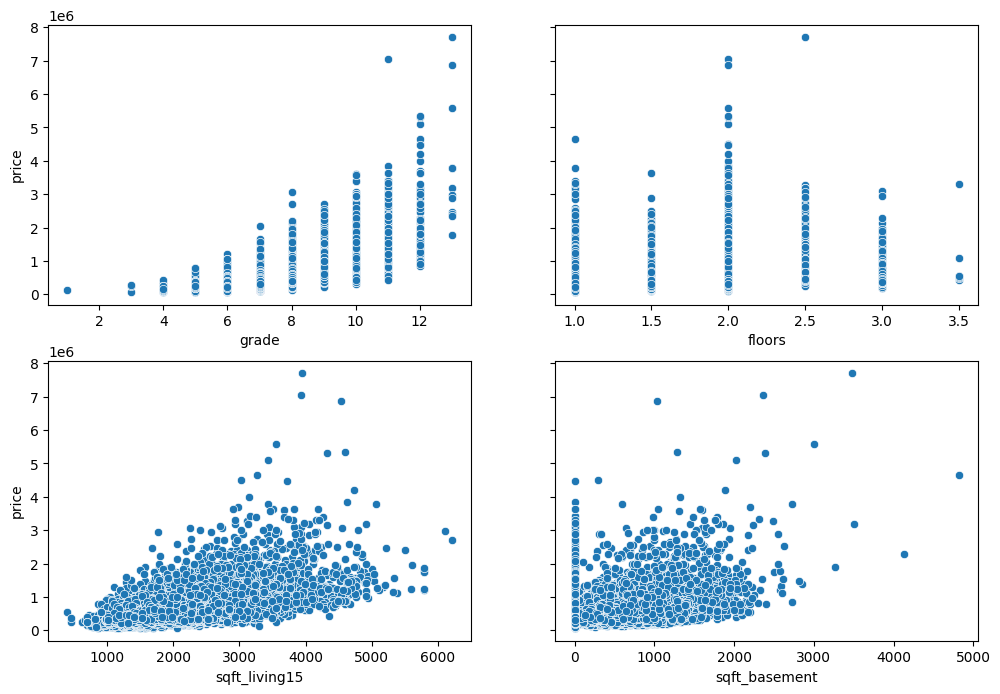

In [ ]:
fig, ax = plt.subplots(2, 2, figsize = (12,8), sharey= True)

# plot for grade vs price
sns.scatterplot(x = 'grade', y = 'price', data = df, ax = ax[0,0])
ax[0,0].set_xlabel('grade')
ax[0,0].set_ylabel('price')

# plot for sqft_living_15 vs price
sns.scatterplot(x = 'sqft_living15', y = 'price', data = df, ax = ax[1,0])
ax[1,0].set_xlabel('sqft_living15')
ax[1,0].set_ylabel('price')

# plt for floors vs price
sns.scatterplot(x = 'floors', y = 'price', data = df, ax = ax[0,1])
ax[0,1].set_xlabel('floors')
ax[0,1].set_ylabel('price')

# plot for sqft_basement vs price
sns.scatterplot(x = 'sqft_basement', y = 'price', data = df, ax = ax[1,1])
ax[1,1].set_xlabel('sqft_basement')
ax[1,1].set_ylabel('price')

From the above four graphs it is observed that:
1) Grade have a good effect on price as we can visually see that as grade increases the price also increses. Even though there are some odd cases it is good feature to depend on to predict.

2) Floors have some impact on price, but the relationship is weak. We should consider floors together with other variables to draw stronger conclusions.

3) sqft_living of nearest 15 has a moderate to good impact on price (0.59). so it is good ti consider it as  parameter iin prediction

4) The relation between sqft_basement and price indicates a positive relationship, though the it is low. However, the finished basement area is likely an important factor in determining the property price, so we can consider it as a parameter or independent variable.

# Model Building

Dividing our data into independent features and target

In [ ]:
# droping zipcode column as it has negative co- relation near to zero with price
df.drop( 'zipcode',axis = 1, inplace = True)

In [ ]:
x = df.drop('price',axis = 1)
y = df['price']

Dividing our data into Training and Testing part

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=1)

In [ ]:
# Importing modules to run keras

import tensorflow as tf
import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.utils import model_to_dot
from tensorflow.keras.utils import plot_model

!pip install livelossplot
import livelossplot
plot_losses =  livelossplot.PlotLossesKeras(figsize = (10,5))

Setting figsize to (10, 5)


In [ ]:
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(x_train.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

In [ ]:
def rmse_loss(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)))

model.compile(optimizer='adam', loss=rmse_loss, metrics=[tf.keras.metrics.R2Score()])

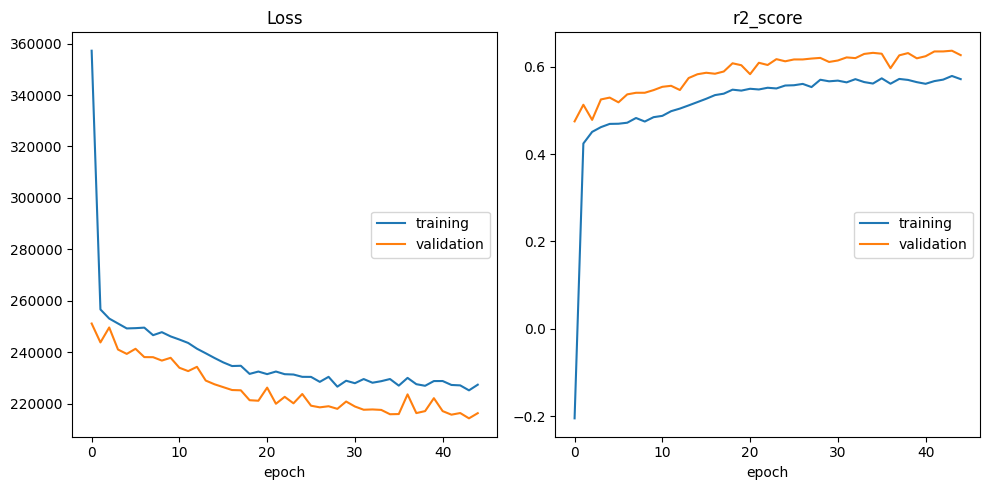

Loss
	training         	 (min: 225225.156, max: 357225.812, cur: 227422.828)
	validation       	 (min: 214346.766, max: 251200.469, cur: 216356.875)
r2_score
	training         	 (min:   -0.205, max:    0.579, cur:    0.572)
	validation       	 (min:    0.475, max:    0.637, cur:    0.627)
541/541 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 231547.5938 - r2_score: 0.5750 - val_loss: 216356.8750 - val_r2_score: 0.6270


In [ ]:
c = model.fit(x_train, y_train, epochs=45, batch_size=32, validation_data=(x_test, y_test),callbacks=[plot_losses])


In [ ]:
loss, rmse = model.evaluate(x_test, y_test)
print(f"Test Loss: {loss:.4f}")

136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 224968.3125 - r2_score: 0.6136
Test Loss: 216356.8750


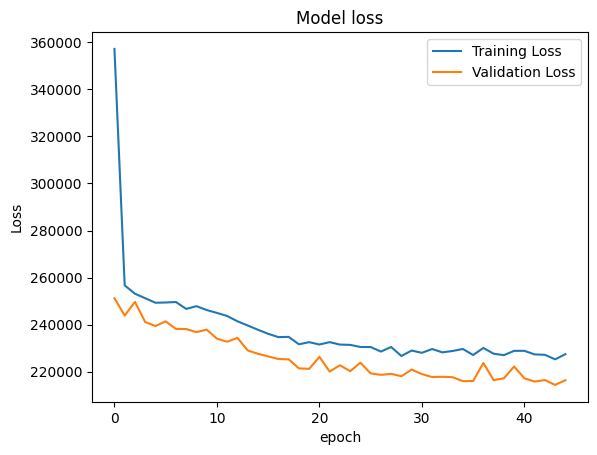

In [ ]:
plt.plot(c.history['loss'], label='Training Loss')
plt.plot(c.history['val_loss'], label='Validation Loss')
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('epoch')
plt.legend()
plt.show()

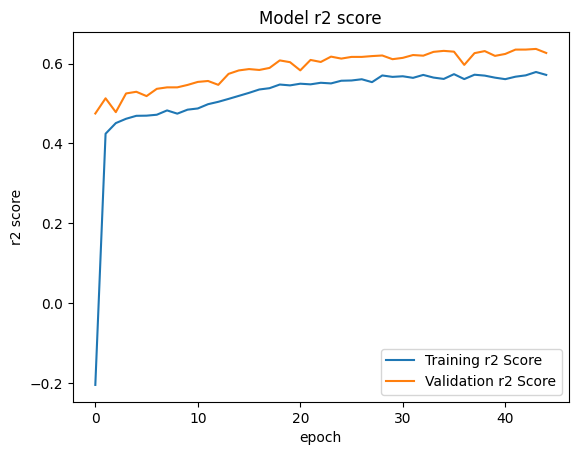

In [ ]:
plt.plot(c.history['r2_score'], label='Training r2 Score')
plt.plot(c.history['val_r2_score'], label='Validation r2 Score')
plt.title('Model r2 score')
plt.ylabel('r2 score')
plt.xlabel('epoch')
plt.legend()

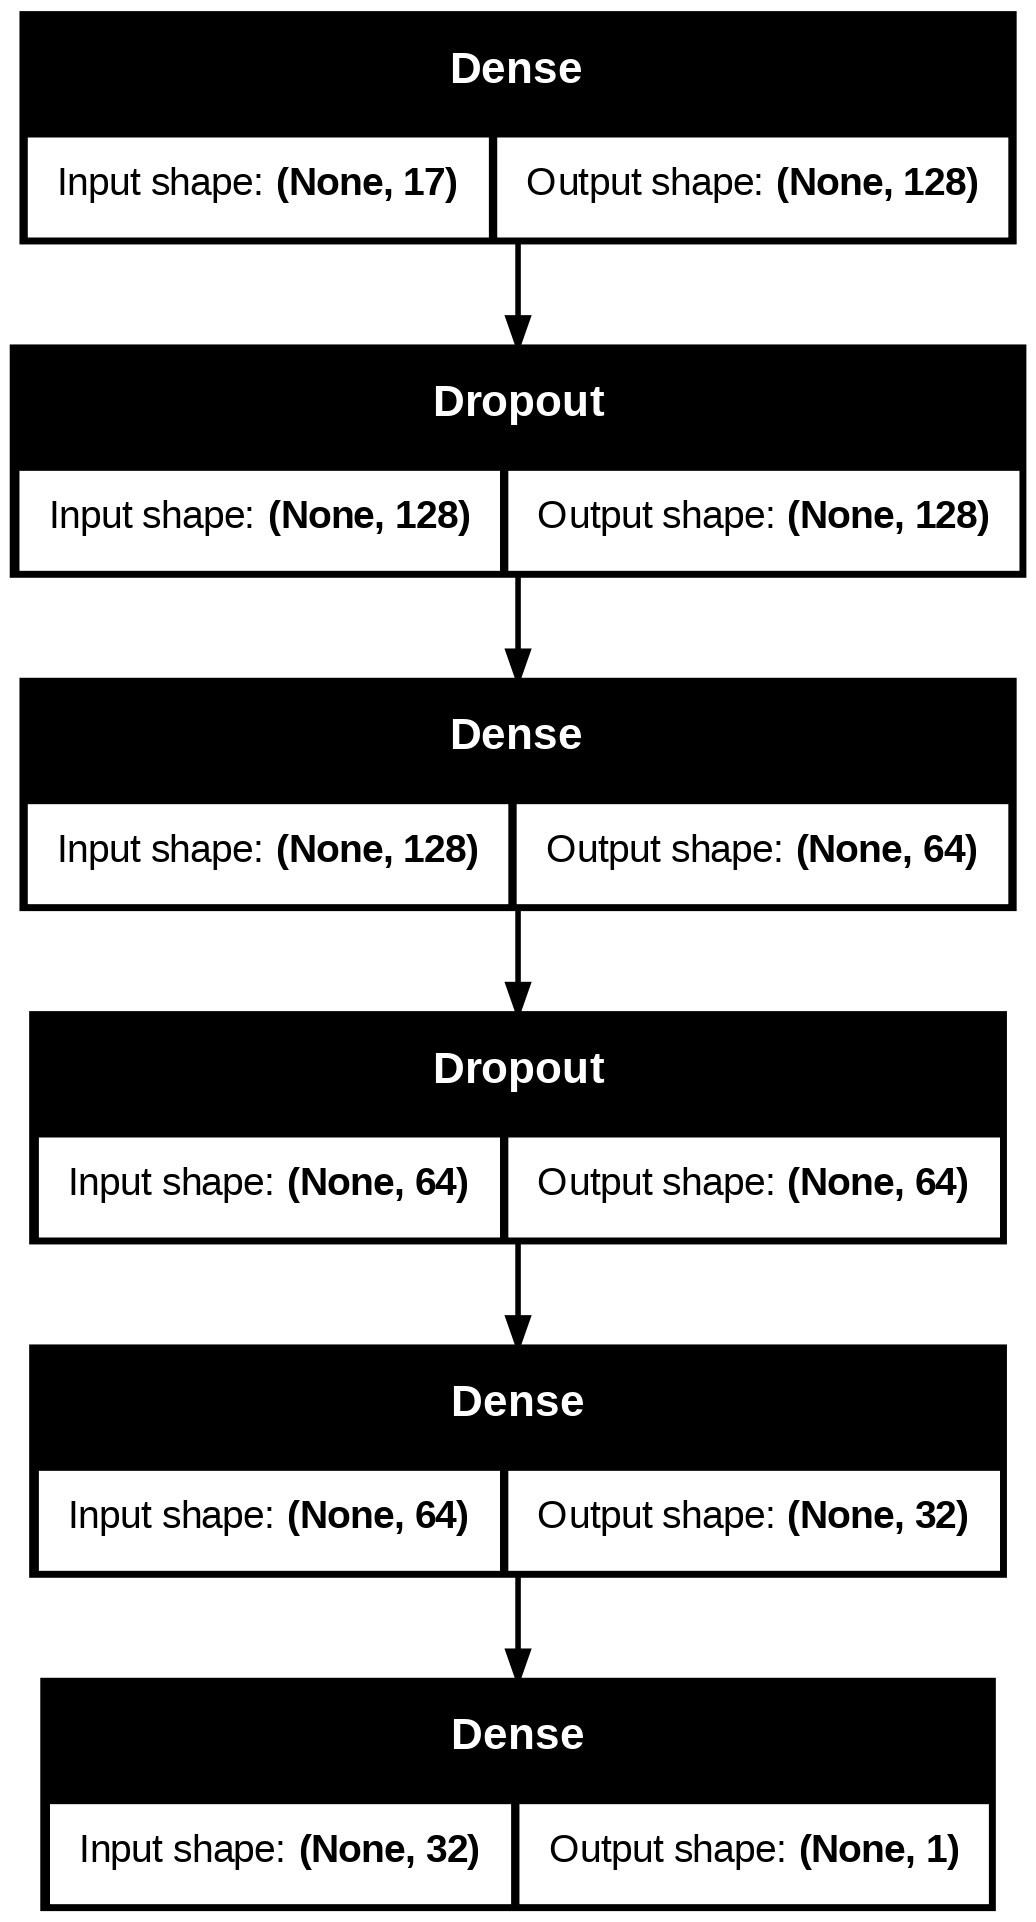

In [ ]:
plot_model(model, to_file='model_plot.png', show_shapes=True)

1) from the above model we got max training_r2 score of 0.57 and max val_r2 score of 0.63 and qoit a lot error. so lets try to improve them

**Let's try to improve the r2 score of our model**

In [ ]:
#sacling our data
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

# New model

In [ ]:
new_model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(x_train.shape[1],)),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout( 0.2),
    layers.Dense(1)
])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

def rmse_loss(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)))

new_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate = 0.0005), loss=rmse_loss, metrics=[tf.keras.metrics.R2Score()])
early_stop = EarlyStopping(monitor='val_r2_score', patience=13, restore_best_weights=True,)

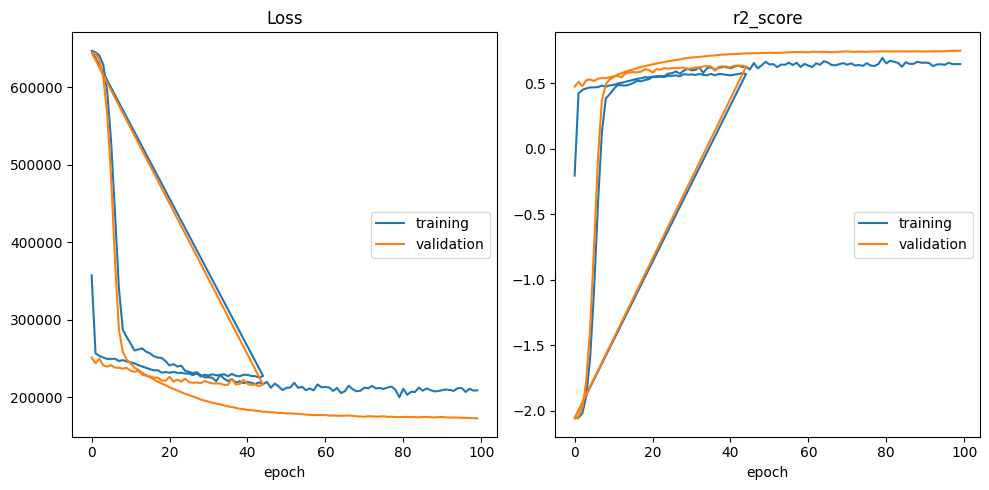

Loss
	training         	 (min: 199847.906, max: 647309.562, cur: 208889.562)
	validation       	 (min: 172680.344, max: 644936.500, cur: 172680.344)
r2_score
	training         	 (min:   -2.059, max:    0.695, cur:    0.648)
	validation       	 (min:   -2.059, max:    0.750, cur:    0.750)
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 200323.9688 - r2_score: 0.6629 - val_loss: 172680.3438 - val_r2_score: 0.7499


In [ ]:
c = new_model.fit(x_test,y_test,epochs=100,batch_size=32,validation_data=(x_test,y_test),callbacks=[plot_losses,early_stop])

In [ ]:
acc, rmse = new_model.evaluate(x_test, y_test)

136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 176259.9219 - r2_score: 0.7642


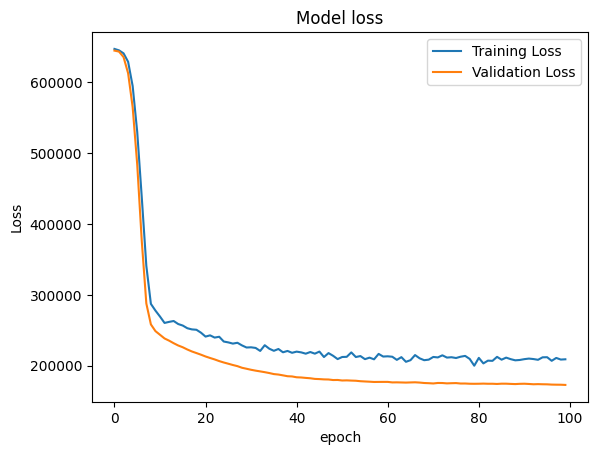

In [ ]:
plt.plot(c.history['loss'], label='Training Loss')
plt.plot(c.history['val_loss'], label='Validation Loss')
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('epoch')
plt.legend()
plt.show()


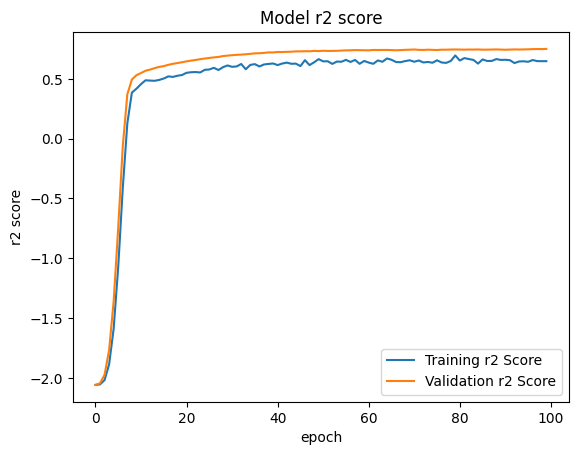

In [ ]:
plt.plot(c.history['r2_score'], label='Training r2 Score')
plt.plot(c.history['val_r2_score'], label='Validation r2 Score')
plt.title('Model r2 score')
plt.ylabel('r2 score')
plt.xlabel('epoch')
plt.legend()

1) By using sacled data for model building we had improve our matrics as below

          training_r2_score : 0.69(max)

          validation_r2_score : 0.75(max)

2) It is good improvment compared to our previous model

3) By the graphs above we can say the model is peforming ok and it is round to the optimized model(not overfitted nor underfitted).

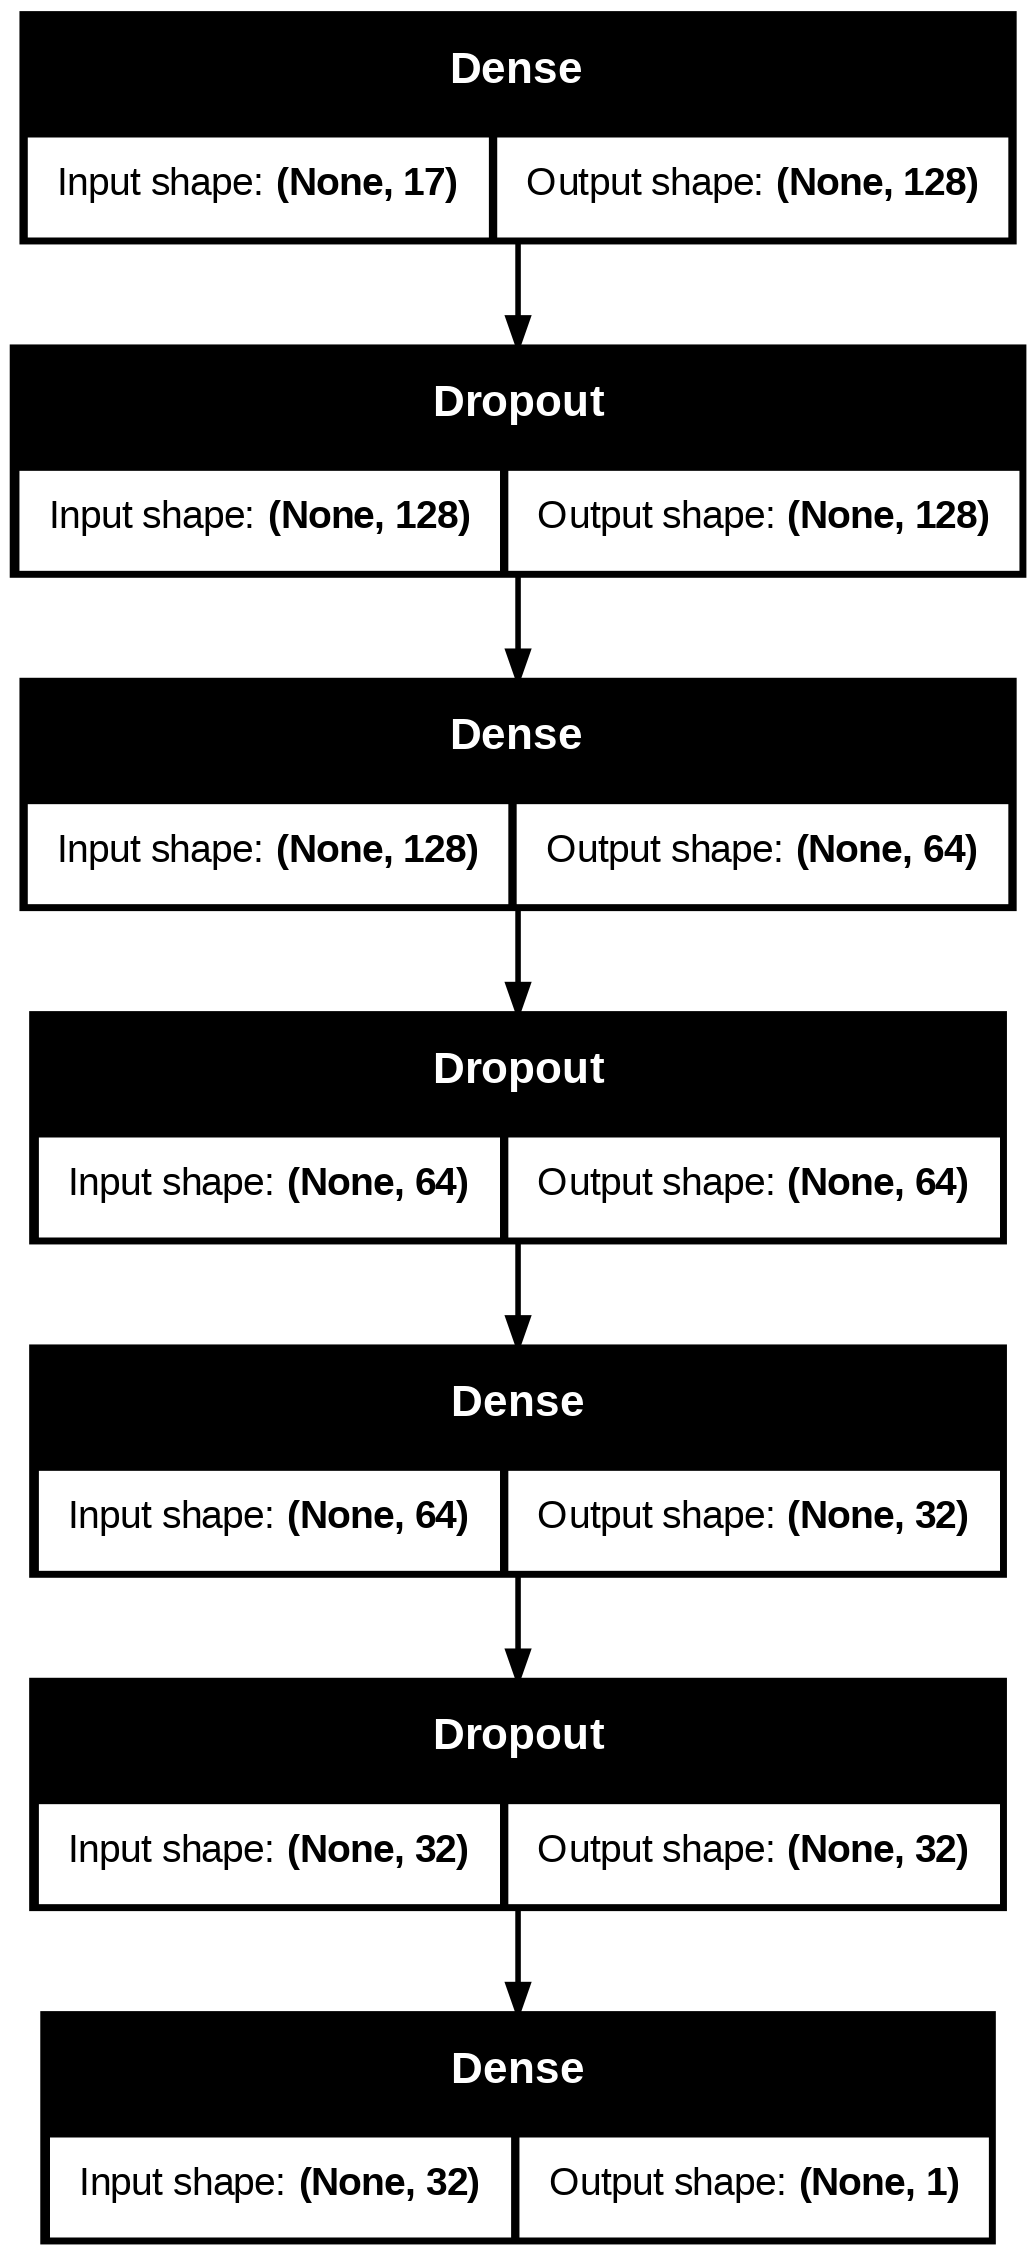

In [ ]:
plot_model(new_model, to_file='model_plot.png', show_shapes=True)

**Let's try using some other parameters and try to improve r2 score**

In [ ]:
new_model3 = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(x_train.shape[1],)),
    layers.Dropout(0.1),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.05),
    layers.Dense(1)
])

In [ ]:
new_model3.compile(optimizer=tf.keras.optimizers.SGD(learning_rate = 0.0001), loss=rmse_loss, metrics=[tf.keras.metrics.R2Score()])
early_stop = EarlyStopping(monitor='val_r2_score', patience=15, restore_best_weights=True,)

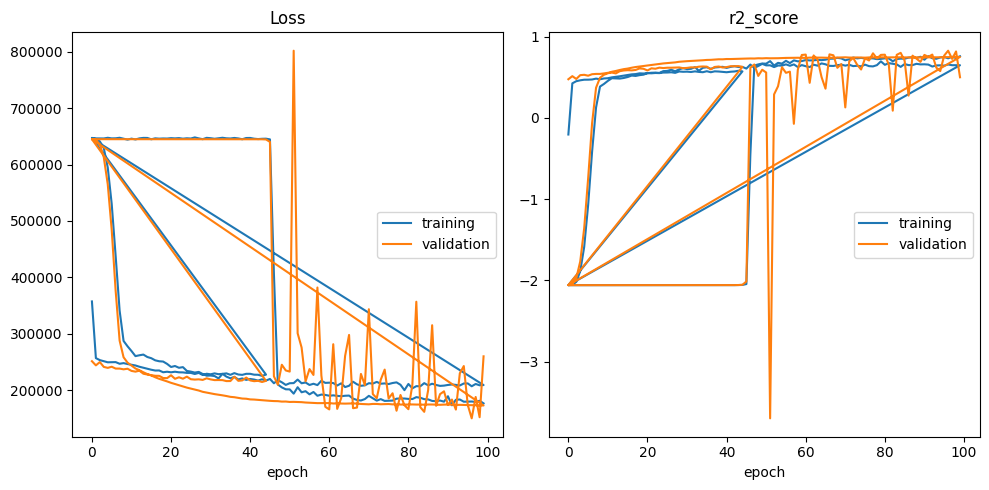

Loss
	training         	 (min: 172992.062, max: 648161.625, cur: 176396.156)
	validation       	 (min: 149873.484, max: 801911.500, cur: 259866.484)
r2_score
	training         	 (min:   -2.060, max:    0.759, cur:    0.758)
	validation       	 (min:   -3.699, max:    0.826, cur:    0.499)
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 169016.2969 - r2_score: 0.7393 - val_loss: 259866.4844 - val_r2_score: 0.4995


In [ ]:
c = new_model3.fit(x_test,y_test,epochs=100,batch_size=32,validation_data=(x_test,y_test),callbacks=[plot_losses,early_stop])

In [ ]:
acc, rmse = new_model3.evaluate(x_test, y_test)

136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 152093.4062 - r2_score: 0.8285


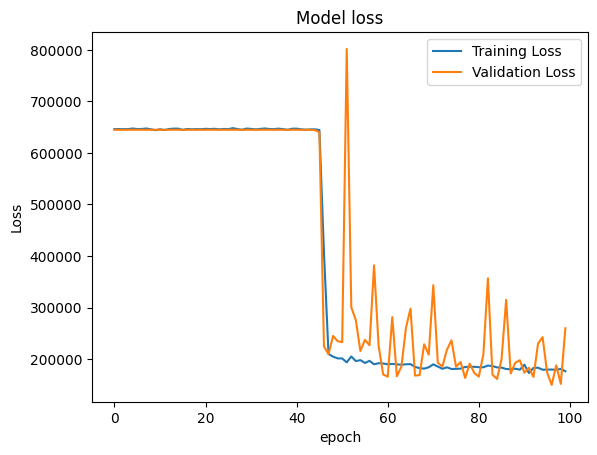

In [ ]:
plt.plot(c.history['loss'], label='Training Loss')
plt.plot(c.history['val_loss'], label='Validation Loss')
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('epoch')
plt.legend()
plt.show()

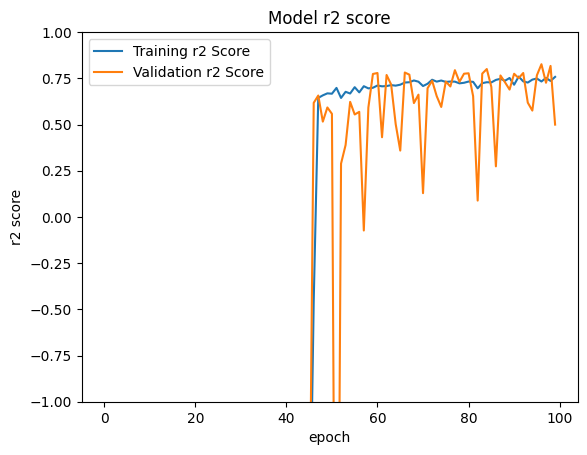

In [ ]:
plt.plot(c.history['r2_score'], label='Training r2 Score')
plt.plot(c.history['val_r2_score'], label='Validation r2 Score')
plt.ylim(-1,1)
plt.title('Model r2 score')
plt.ylabel('r2 score')
plt.xlabel('epoch')
plt.legend()

1) By changing some parameters we got the metrices as

        training_r2_score : 0.75 (max)

        validation_r2_score : 0.82 (max)

2) The results got improved for this model compared to previous models.

3) But when we observe the above graphs, it is observed that the validation r2 score has a lot of noise, which is not good. so we can consider the prvious model as our best.

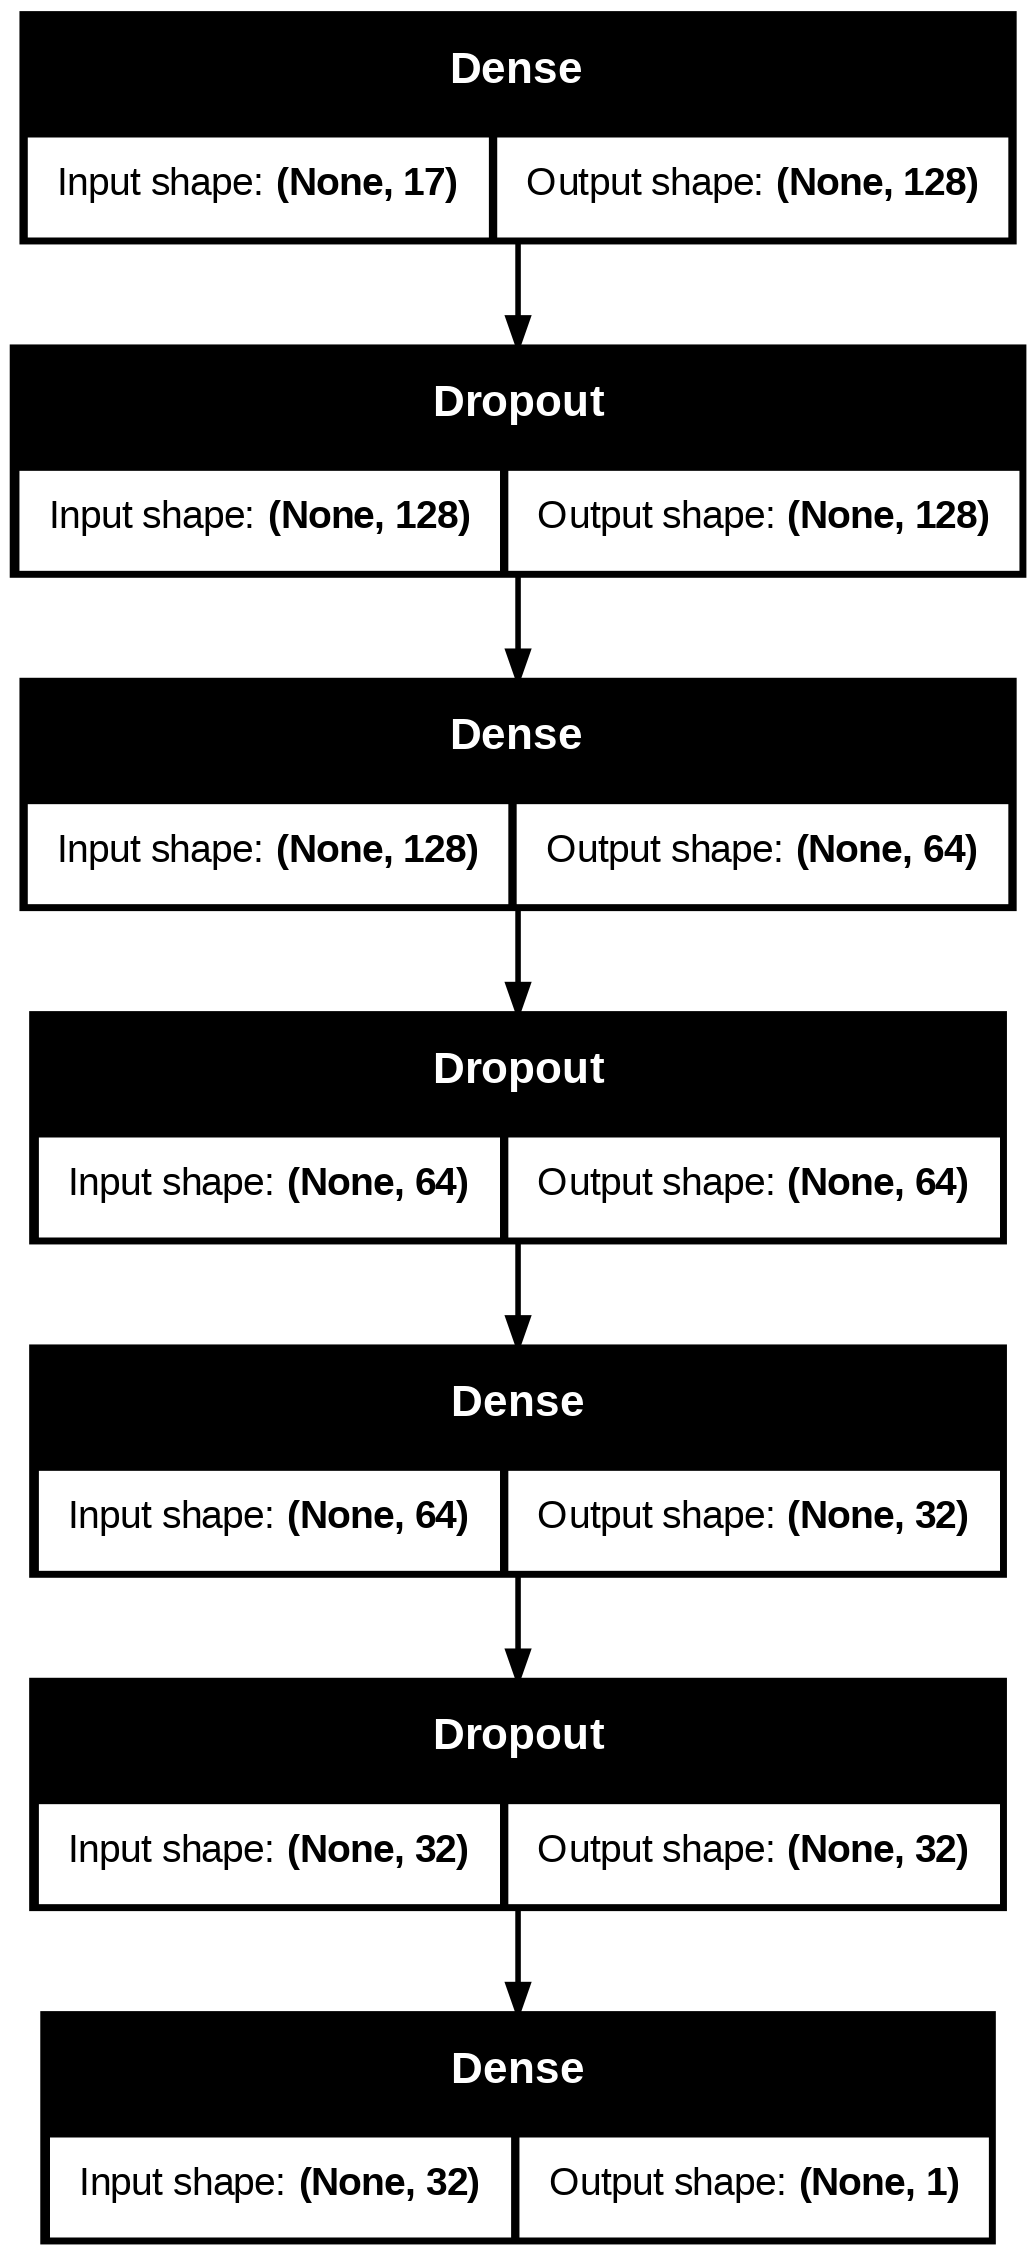

In [ ]:
plot_model(new_model3, to_file='model_plot.png', show_shapes=True)